In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [23]:
df = pd.read_csv("Employee Attrition Data.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [24]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [26]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [27]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [28]:
numerical_df = df.select_dtypes(include = ['number'])
categorical_df = df.select_dtypes(include = ['object', 'category'])
categorical_cols = categorical_df.columns.tolist()

In [29]:
zero_var_cols = numerical_df.columns[numerical_df.std() == 0].tolist()
numerical_df = numerical_df.drop(columns=zero_var_cols)
numerical_cols = numerical_df.columns.tolist()

C:\Users\Admin\AppData\Local\Temp\ipykernel_2376\1114001938.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=col, hue='Attrition', fill=True, common_norm=False)


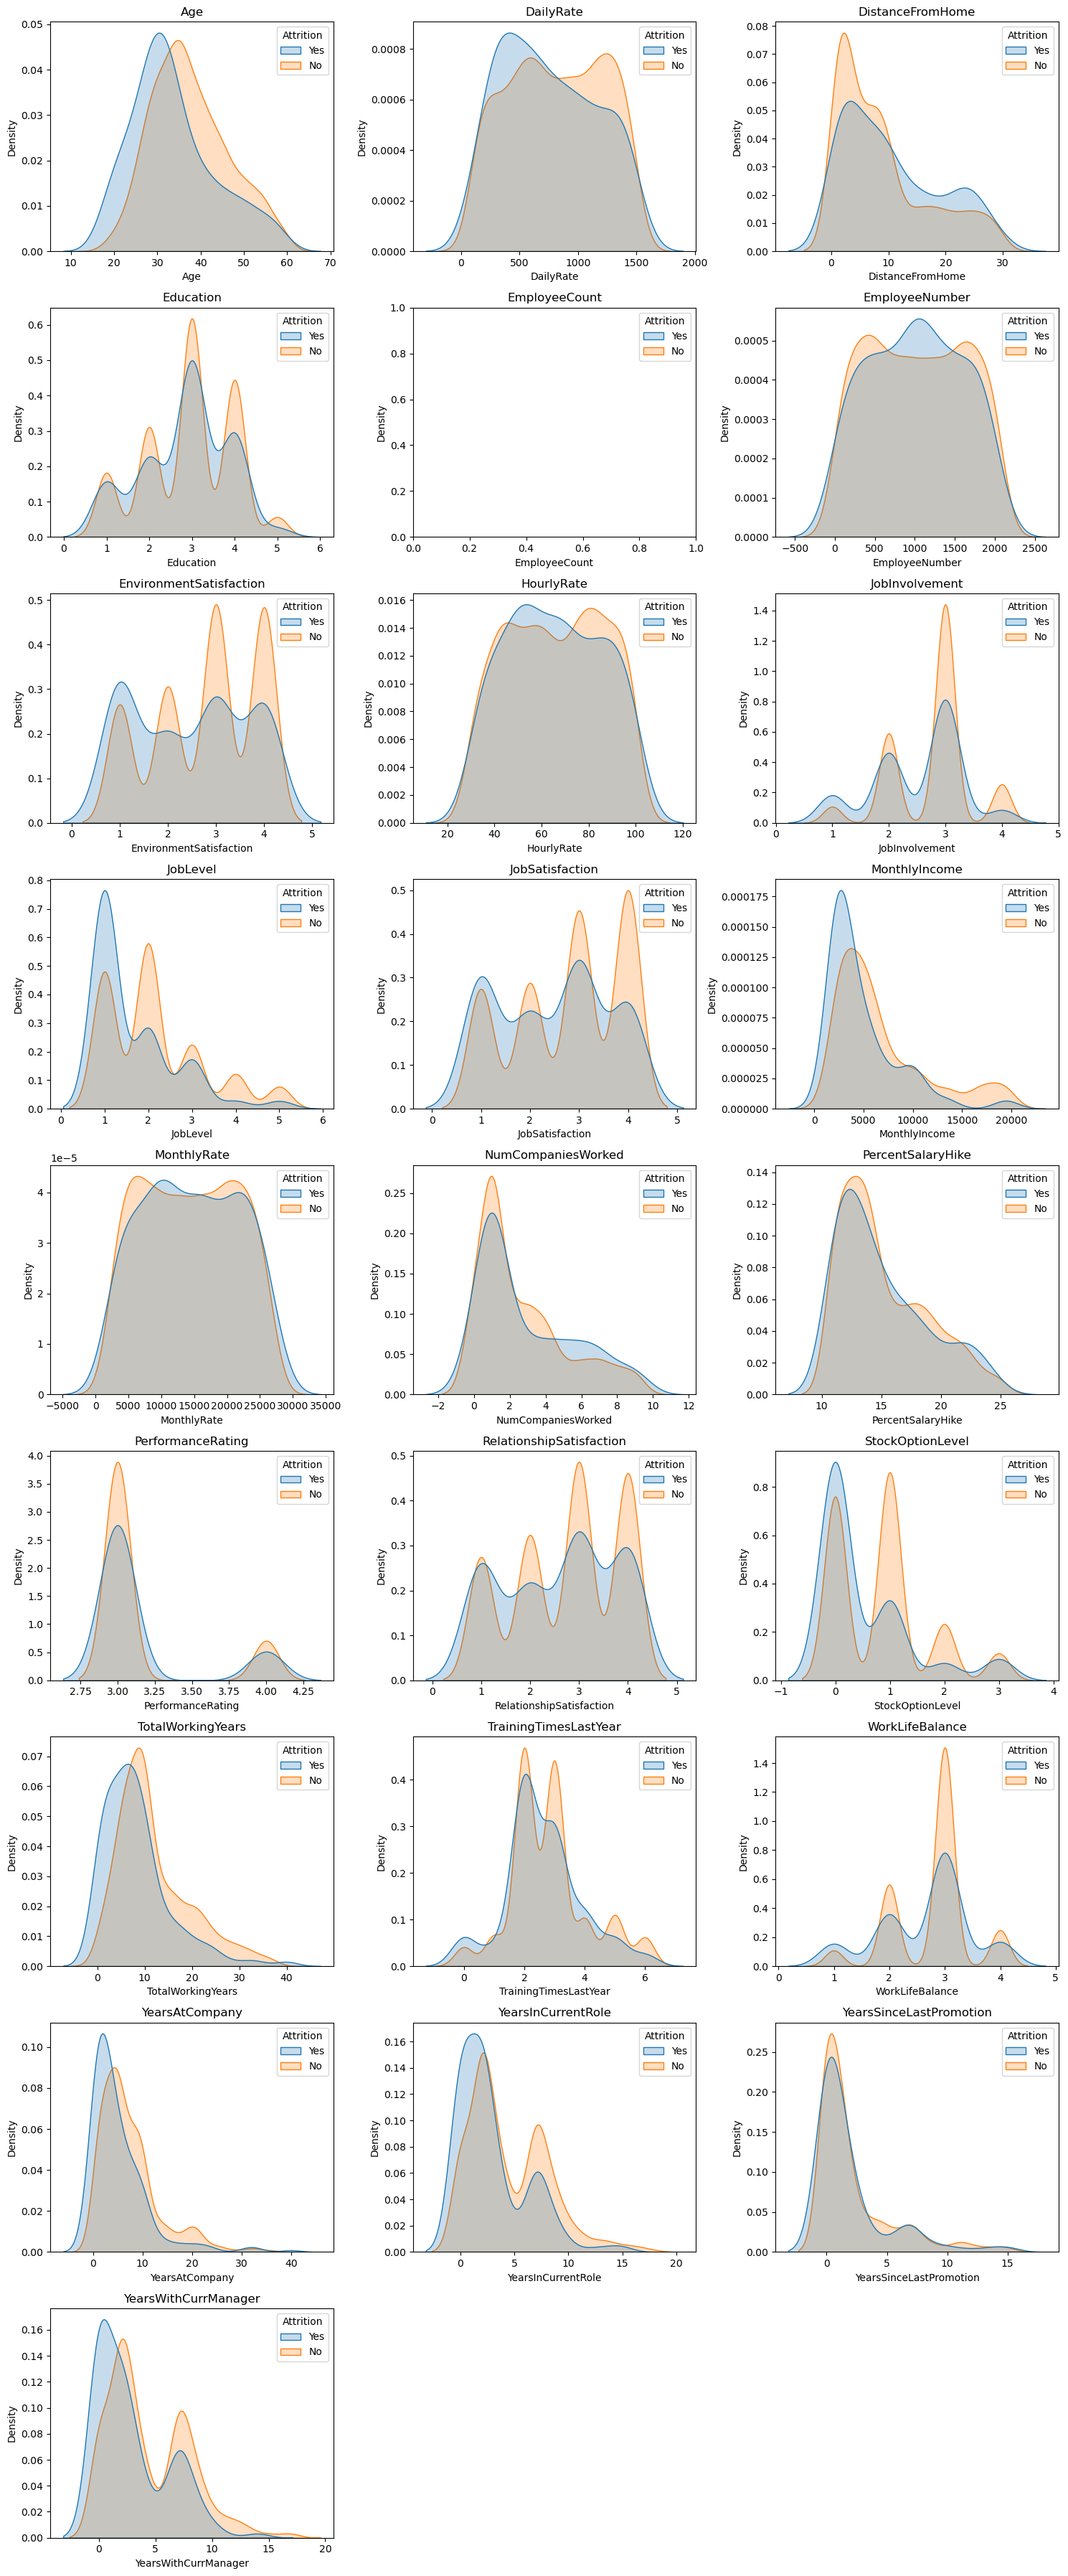

In [30]:
n_features = len(numerical_cols)
cols = 3
rows = math.ceil(n_features / cols)

plt.figure(figsize=(15, rows * 4))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.kdeplot(data=df, x=col, hue='Attrition', fill=True, common_norm=False)
    plt.title(f'{col}')

plt.tight_layout()
plt.show()

In [31]:
useful_numerical_columns = ['Age','DistanceFromHome','JobLevel','JobSatisfaction','MonthlyIncome','StockOptionLevel','TotalWorkingYears','YearsAtCompany','YearsInCurrentRole','YearsWithCurrManager']

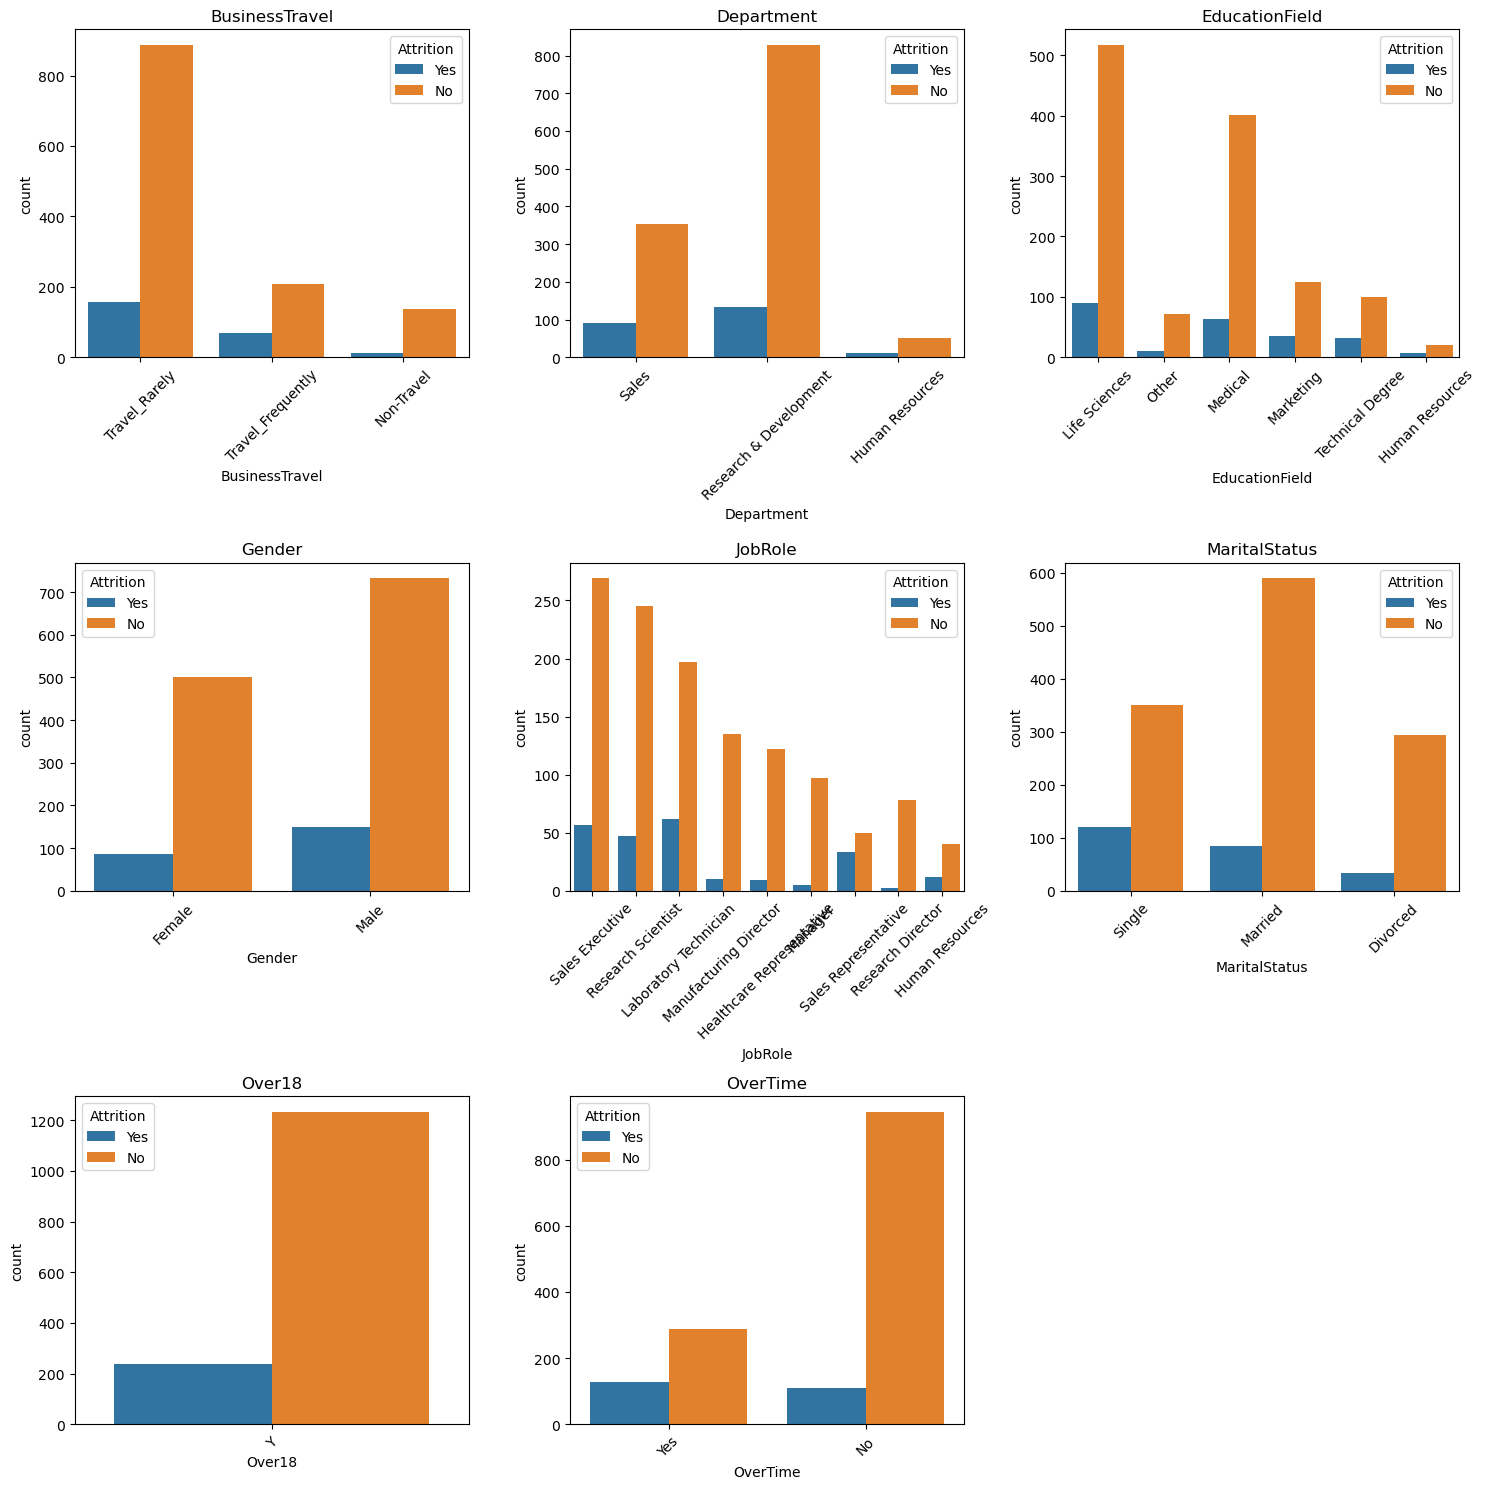

In [32]:
# Countplot method
cat_features = [col for col in categorical_cols if col != 'Attrition']
n_cat_features = len(cat_features)
cols = 3
rows = math.ceil(n_cat_features / cols)

plt.figure(figsize=(15, rows * 5))

for i, col in enumerate(cat_features, 1):
    plt.subplot(rows, cols, i)
    sns.countplot(data=df, x=col, hue='Attrition')
    plt.title(f'{col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [33]:
# Chi-Square Test of Independence

from scipy.stats import chi2_contingency
chi2_results = []

for col in cat_features:
    contingency_table = pd.crosstab(df[col], df['Attrition'])

    chi2, p, dof, expected = chi2_contingency(contingency_table)

    chi2_results.append({'Feature': col, 'P-value': p})

chi_df = pd.DataFrame(chi2_results).sort_values(by='P-value')

print(chi_df)


          Feature       P-value
7        OverTime  8.158424e-21
4         JobRole  2.752482e-15
5   MaritalStatus  9.455511e-11
0  BusinessTravel  5.608614e-06
1      Department  4.525607e-03
2  EducationField  6.773980e-03
3          Gender  2.905724e-01
6          Over18  1.000000e+00


In [34]:
useful_categorical_columns = ['OverTime','JobRole','MaritalStatus','BusinessTravel','Department','EducationField','Attrition'] 

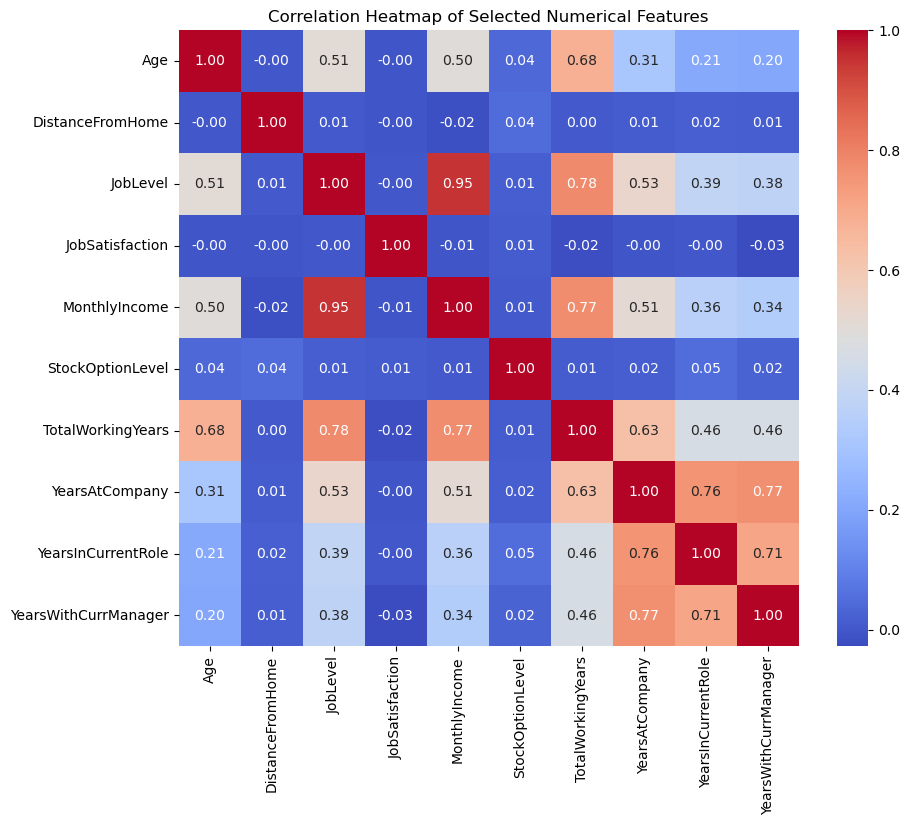

In [35]:
# Checking Multicollinearity
corr_matrix = df[useful_numerical_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Selected Numerical Features")
plt.show()

In [36]:
useful_numerical_columns = [col for col in useful_numerical_columns if col != 'JobLevel']

In [37]:
final_features = []
final_features.extend(useful_numerical_columns)
final_features.extend(useful_categorical_columns)
print(final_features)

['Age', 'DistanceFromHome', 'JobSatisfaction', 'MonthlyIncome', 'StockOptionLevel', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager', 'OverTime', 'JobRole', 'MaritalStatus', 'BusinessTravel', 'Department', 'EducationField', 'Attrition']


In [38]:
df = df[final_features]
df.head()

,Age,DistanceFromHome,JobSatisfaction,MonthlyIncome,StockOptionLevel,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager,OverTime,JobRole,MaritalStatus,BusinessTravel,Department,EducationField,Attrition
0,41,1,4,5993,0,8,6,4,5,Yes,Sales Executive,Single,Travel_Rarely,Sales,Life Sciences,Yes
1,49,8,2,5130,1,10,10,7,7,No,Research Scientist,Married,Travel_Frequently,Research & Development,Life Sciences,No
2,37,2,3,2090,0,7,0,0,0,Yes,Laboratory Technician,Single,Travel_Rarely,Research & Development,Other,Yes
3,33,3,3,2909,0,8,8,7,0,Yes,Research Scientist,Married,Travel_Frequently,Research & Development,Life Sciences,No
4,27,2,2,3468,1,6,2,2,2,No,Laboratory Technician,Married,Travel_Rarely,Research & Development,Medical,No


In [39]:
df['Attrition'] = df['Attrition'].apply(lambda x: 1 if x=='Yes' else 0)

In [40]:
cat_features_for_dummies = [col for col in useful_categorical_columns if col != 'Attrition']

In [41]:
df = pd.get_dummies(df,columns = cat_features_for_dummies, drop_first=True, dtype=int)
df.head()

,Age,DistanceFromHome,JobSatisfaction,MonthlyIncome,StockOptionLevel,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager,Attrition,...,MaritalStatus_Single,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree
0,41,1,4,5993,0,8,6,4,5,1,...,1,0,1,0,1,1,0,0,0,0
1,49,8,2,5130,1,10,10,7,7,0,...,0,1,0,1,0,1,0,0,0,0
2,37,2,3,2090,0,7,0,0,0,1,...,1,0,1,1,0,0,0,0,1,0
3,33,3,3,2909,0,8,8,7,0,0,...,0,1,0,1,0,1,0,0,0,0
4,27,2,2,3468,1,6,2,2,2,0,...,0,0,1,1,0,0,0,1,0,0


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, roc_auc_score

X = df.drop(columns=['Attrition'])
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


useful_numerical_columns = ['Age', 'DistanceFromHome', 'JobSatisfaction', 
                            'MonthlyIncome', 'StockOptionLevel', 'TotalWorkingYears', 
                            'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[useful_numerical_columns] = scaler.fit_transform(X_train[useful_numerical_columns])
X_test_scaled[useful_numerical_columns] = scaler.transform(X_test[useful_numerical_columns])

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)


y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f"Recall Score: {recall_score(y_test, y_pred):.4f}")
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.4f}")



Recall Score: 0.6170
AUC-ROC Score: 0.7544
